<a href="https://colab.research.google.com/github/leahkb/Boyle_NEUR265/blob/main/homework/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Leah Boyle
<i> Neural Data Analysis </i>
<br>
<b> April 5, 2026 </b>


In [3]:
#2. Import the libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


In [8]:
#3. Import data
url = "https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv"
fear_traces = np.loadtxt(url, delimiter=',')

url2 = "https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv"
extinction_predictors = np.loadtxt(url2)

#syntax from homework on 4/2
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)


In [13]:
#check the data

print(fear_traces.shape) #traces in column, sample in rows
print(extinction_predictors.shape)
print(shock_index.shape, tone_index.shape)

(24668, 63)
(14211,)
(3,) (3,)


In [56]:
#5. create conditioning_traces and extinction_traces
conditioning_traces = fear_traces[:10458]
extinction_traces = fear_traces[10459:]


In [57]:
#6. Print out the sizes

print(len(conditioning_traces), conditioning_traces.shape) #row 0 through 10458
print(len(extinction_traces), extinction_traces.shape) #row 10459 to end

10458 (10458, 63)
14209 (14209, 63)


In [60]:
#7. Create time_conditioning and time_extinction variables
fps = 15
samples_c = 10458
samples_e = 14209

#total time is the amount of samples divided by samples per second
time_c = samples_c / 15
time_e = samples_e / 15
print("time c:", time_c, " | time e:", time_e)

#Create arrays
time_conditioning = np.linspace(0, time_c, samples_c)
time_extinction = np.linspace(0, time_e, samples_e)

print(time_conditioning[0], time_conditioning[-1], len(time_conditioning))
print(time_extinction[0], time_extinction[-1], len(time_extinction))

print("total time: ", time_c + time_e, "s")
print("total times: ", time_c/60 , time_e/60, "mins")

time c: 697.2  | time e: 947.2666666666667
0.0 697.2 10458
0.0 947.2666666666667 14209
total time:  1644.4666666666667 s
total times:  11.620000000000001 15.787777777777778 mins


8. The total number of ROIs that were imaged during these sessions was 63 because that is the number of  columns. The total time in seconds is 697.26 for conditioning + 947.36 for extinction = 1644.53. The total time in minutes is 11.62 for conditioning and 15.78 for extinction.

Text(0, 0.5, 'ROIs 1 and 2')

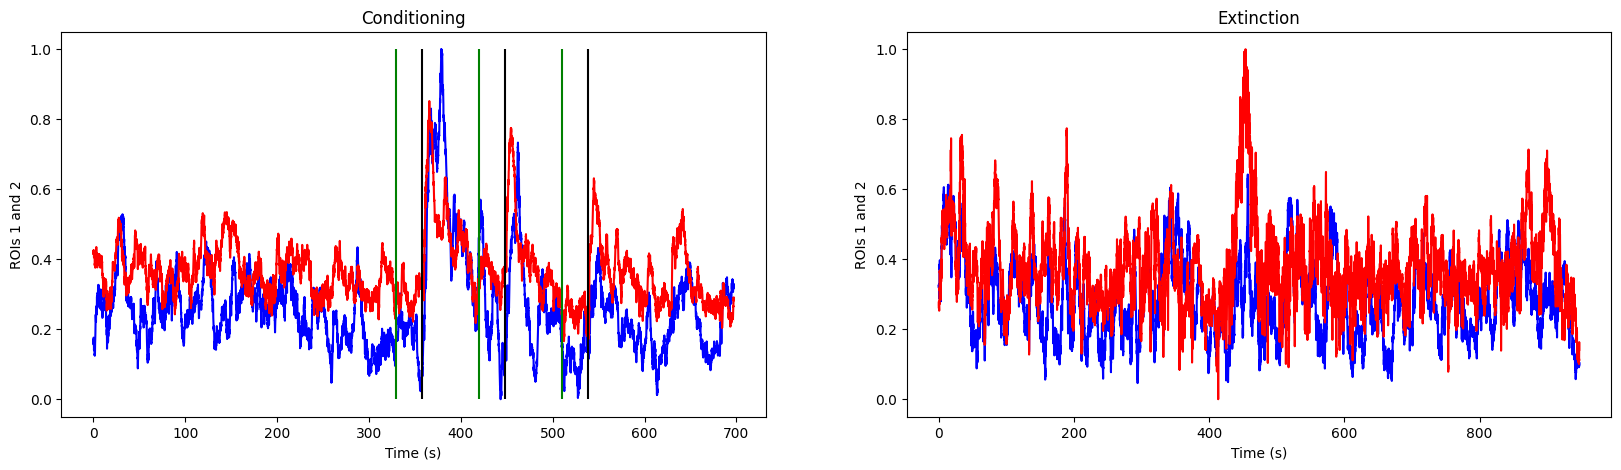

In [61]:
#9. plot the first and second ROIs from the extinction_traces and conditioning_traces

fig, ax = plt.subplots(1,2, figsize=(20,5))

ax[0].plot(time_conditioning, conditioning_traces[:,0], color='blue')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color='red')
ax[0].vlines(shock_index, 0, 1, color ='black')
ax[0].vlines(tone_index, 0, 1 , color ='green')

ax[0].set_title("Conditioning")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('ROIs 1 and 2')

ax[1].plot(time_extinction, extinction_traces[:, 0], color='blue')
ax[1].plot(time_extinction, extinction_traces[:, 1], color='red')

ax[1].set_title("Extinction")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('ROIs 1 and 2')

10. It seems like that at the time points of shock administration during conditioning, the cells had a similar reaction in the extinction phase. This holds true for both cells, but it seems to be more present for the first second ROI (red), because the spike is greater during the extinction phase.

In [62]:
#12. Use the classwork to create shock_array and tone_array variables

#Code from the in class notebook on 4/2
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

from pandas import DataFrame as df
#Create the predictors
predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})

(10458, 63)
(10458,)
(10458,)
(10458, 3)
Intercept      float64
tone onset     float64
shock onset    float64
dtype: object


Text(0, 0.5, ' Proportion of ROIs')

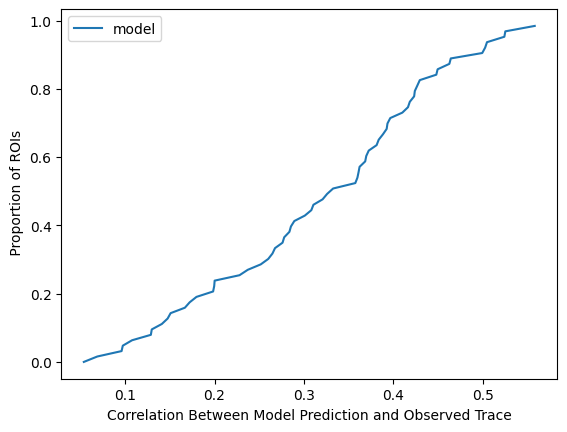

In [65]:
#13. Create r_model_conditioning
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

predictors_conditioning['shock onset'] = shock_array
r_index_conditioning = np.zeros(conditioning_traces.shape[1])

#Checking shapes because there was a problem
print(conditioning_traces.shape)
print(tone_array.shape)
print(shock_array.shape)
print(predictors_conditioning.shape)
print(predictors_conditioning.dtypes)


for i in range(conditioning_traces.shape[1]):
  trace_temp = conditioning_traces[:,i]
  model = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()

  r = pearsonr(trace_temp, predicted_trace)
  r_index_conditioning[i] = r.statistic

plt.plot(np.sort(r_index_conditioning), np.linspace(0, 1, len(r_index_conditioning), endpoint=False), label = "model")
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel(' Proportion of ROIs')

(14209, 63)
(14209,)
(14209,)
(14209, 3)
Intercept      float64
tone onset     float64
shock onset    float64
dtype: object


Text(0, 0.5, ' Proportion of ROIs')

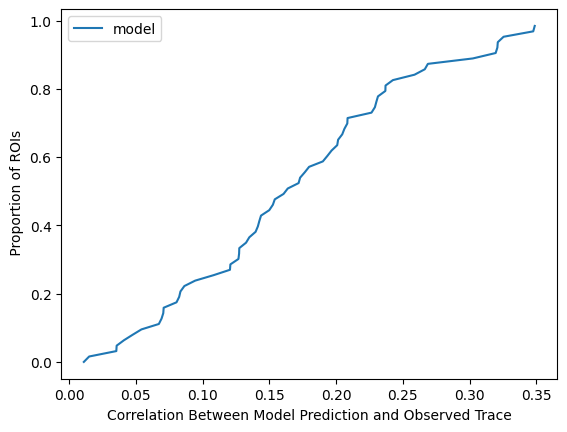

In [67]:
#14. Do the same thing for extinction traces

#Code from the in class notebook on 4/2 -- fix the lenght of predictors array
shock_array = np.zeros(14209)
for i in range(14209):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(14209)
for i in range(14209):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

#make new predictors
predictors_extinction = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_extinction['shock onset'] = shock_array
r_index_extinction = np.zeros(extinction_traces.shape[1])

#Checking shapes because there was a problem
print(extinction_traces.shape)
print(tone_array.shape)
print(shock_array.shape)
print(predictors_extinction.shape)
print(predictors_extinction.dtypes)


for i in range(extinction_traces.shape[1]):
  trace_temp = extinction_traces[:,i]
  model = sm.GLM(trace_temp, predictors_extinction, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()

  r = pearsonr(trace_temp, predicted_trace)
  r_index_extinction[i] = r.statistic

plt.plot(np.sort(r_index_extinction), np.linspace(0, 1, len(r_index_extinction), endpoint=False), label = "model")
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel(' Proportion of ROIs')

In [68]:
#15. use pearsonr function to correlate the r variables

r, p = pearsonr(r_index_conditioning, r_index_extinction)
print("Correlation:", r)
print("pvalue:", p)

Correlation: 0.4399336389518286
pvalue: 0.000308824196526625


Text(0, 0.5, 'correlation value: extinction')

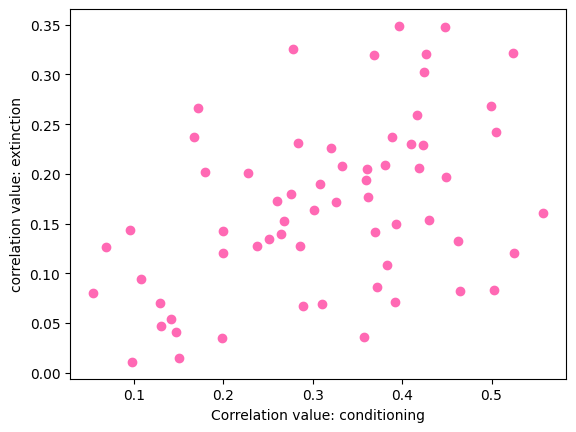

In [70]:
#16. Create the scatter plot with r_indexconditioning/extinction values

plt.scatter(r_index_conditioning, r_index_extinction, color="hotpink")
plt.xlabel("Correlation value: conditioning")
plt.ylabel("correlation value: extinction")

The correlation value is about 0.43 which does not seem very high. This is significant because the p value is < 0.05. Similarly, the scatter plot shows that the correlation value for each of the ROIs is not very high, but it is existent. There is a semblance of a line forming. This means that the strength that the cell responds to the onset during the conditioning predicts a slightly stronger response during the extinction session.